# Voxel Encoding

In [1]:
%%capture
! pip install himalaya

In [2]:
!pip install --upgrade scipy

You should consider upgrading via the '/gpfs/home1/scur0412/NeuroNLP/neuro/bin/python -m pip install --upgrade pip' command.


In [11]:
import os
import numpy as np
from scipy.io import loadmat
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.scoring import correlation_score 
import matplotlib.pyplot as plt

In [2]:
# For the .mat files (Experiment 2 and Experiment 3)
mat_exp3 = "/home/scur0412/NeuroNLP/data/participants/M02/data_243sentences.mat"
mat_exp2 = "/home/scur0412/NeuroNLP/data/participants/M02/data_384sentences.mat"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen Embedder
embed_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment2_384"
embed_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment3_243"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen
llm_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment2_384"
llm_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment3_243"
num_layers = 37

In [3]:
def get_language_responses(mat_path):
    data = loadmat(mat_path, simplify_cells=True)
    target_index = np.where(data['meta']['atlases'] == 'languageLH')[0].item()
    column_indexes = np.concatenate([arr - 1 for arr in data['meta']['roiColumns'][target_index]], axis=0)
    # brain_responses = data['examples_passages'][:, column_indexes]
    brain_responses = data['examples_passagesentences'][:, column_indexes]
    print(f"Dimensionality of brain responses: {brain_responses.shape}")
    return brain_responses

In [4]:
y_exp2 = get_language_responses(mat_exp2)
y_exp3 = get_language_responses(mat_exp3)


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Dimensionality of brain responses: (384, 4930)
Dimensionality of brain responses: (243, 4930)


In [5]:
Y = np.concatenate([y_exp2, y_exp3], axis=0)

In [6]:
n_splits = 5
kf = KFold(n_splits=n_splits)
alphas = np.logspace(1, 20, 20)
_, n_voxels = Y.shape

layer_performances = {}

In [7]:
# Initialize dictionaries to store performance for both models
layer_performances = {}  # For Qwen model
layer_performances_embedding = {}  # For Qwen Embedding model


for layer_idx in range(num_layers):
    # Load the embeddings for the Qwen model (exp2 and exp3)
    x_exp2 = np.load(os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3 = np.load(os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X = np.concatenate([x_exp2, x_exp3], axis=0)

    accs_train = np.empty((n_splits, n_voxels))
    accs_test = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen model
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen model
    mean_test_acc = accs_test.mean(axis=0).mean()
    mean_train_acc = accs_train.mean(axis=0).mean()
    layer_performances[layer_idx] = mean_test_acc
    
    print(f"Qwen Model - Layer {layer_idx} Test Accuracy: {mean_test_acc:.4f}")
    print(f"Qwen Model - Layer {layer_idx} Train Accuracy: {mean_train_acc:.4f}")

    # Now for Qwen Embedding Model - repeat the process with its respective embeddings
    # Load the embeddings for Qwen Embedding model (exp2 and exp3)
    x_exp2_embedding = np.load(os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3_embedding = np.load(os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X_embedding = np.concatenate([x_exp2_embedding, x_exp3_embedding], axis=0)

    accs_train_embedding = np.empty((n_splits, n_voxels))
    accs_test_embedding = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen Embedding model
    for i, (train_index, test_index) in enumerate(kf.split(X_embedding)):
        X_train, X_test = X_embedding[train_index, :], X_embedding[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train_embedding[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test_embedding[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen Embedding model
    mean_test_acc_embedding = accs_test_embedding.mean(axis=0).mean()
    mean_train_acc_embedding = accs_train_embedding.mean(axis=0).mean()
    layer_performances_embedding[layer_idx] = mean_test_acc_embedding
    
    print(f"Qwen Embedding Model - Layer {layer_idx} Test Accuracy: {mean_test_acc_embedding:.4f}")
    print(f"Qwen Embedding Model - Layer {layer_idx} Train Accuracy: {mean_train_acc_embedding:.4f}")

Qwen Model - Layer 0 Test Accuracy: -0.0056
Qwen Model - Layer 0 Train Accuracy: 0.0391
Qwen Embedding Model - Layer 0 Test Accuracy: 0.0000
Qwen Embedding Model - Layer 0 Train Accuracy: 0.0000
Qwen Model - Layer 1 Test Accuracy: 0.1526
Qwen Model - Layer 1 Train Accuracy: 0.3461
Qwen Embedding Model - Layer 1 Test Accuracy: 0.1637
Qwen Embedding Model - Layer 1 Train Accuracy: 0.3698
Qwen Model - Layer 2 Test Accuracy: 0.1325
Qwen Model - Layer 2 Train Accuracy: 0.3263
Qwen Embedding Model - Layer 2 Test Accuracy: 0.1805
Qwen Embedding Model - Layer 2 Train Accuracy: 0.4090
Qwen Model - Layer 3 Test Accuracy: 0.1179
Qwen Model - Layer 3 Train Accuracy: 0.2987
Qwen Embedding Model - Layer 3 Test Accuracy: 0.1951
Qwen Embedding Model - Layer 3 Train Accuracy: 0.4326
Qwen Model - Layer 4 Test Accuracy: 0.1636
Qwen Model - Layer 4 Train Accuracy: 0.3712
Qwen Embedding Model - Layer 4 Test Accuracy: 0.2178
Qwen Embedding Model - Layer 4 Train Accuracy: 0.4576
Qwen Model - Layer 5 Test Acc

In [8]:
output_dir = "/home/scur0412/NeuroNLP/results"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "qwen_layer_performances.npy")
np.save(output_file, layer_performances)

output_file_embedding = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")
np.save(output_file_embedding, layer_performances_embedding)

In [9]:
output_dir = "/home/scur0412/NeuroNLP/results"
output_file = os.path.join(output_dir, "qwen_layer_performances.npy")

qwen_embedding_output_file = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")

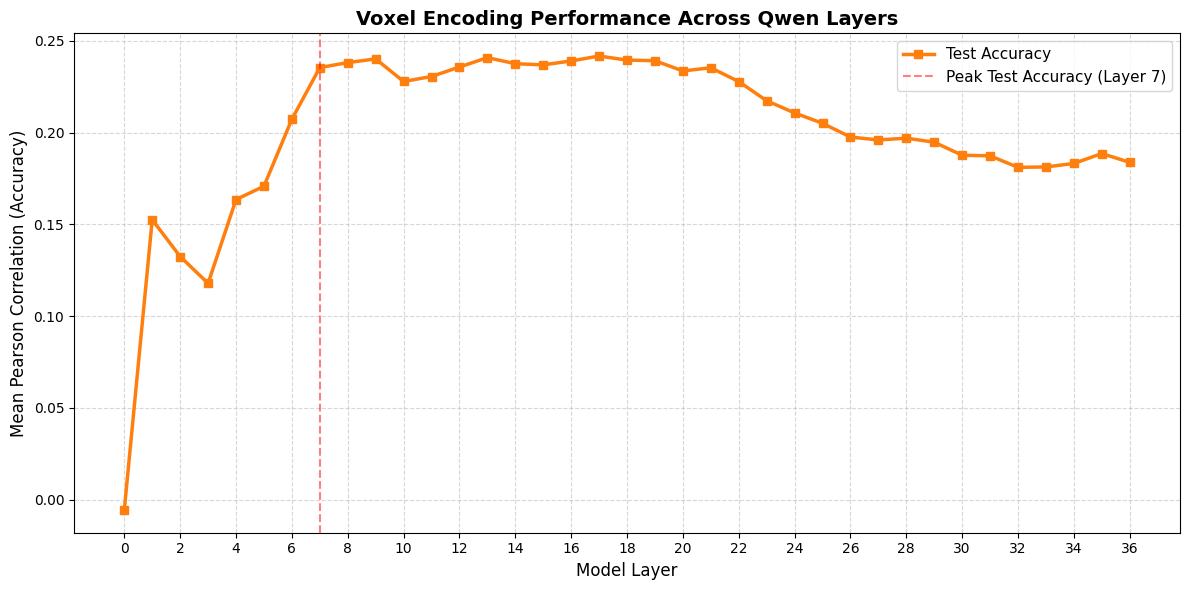

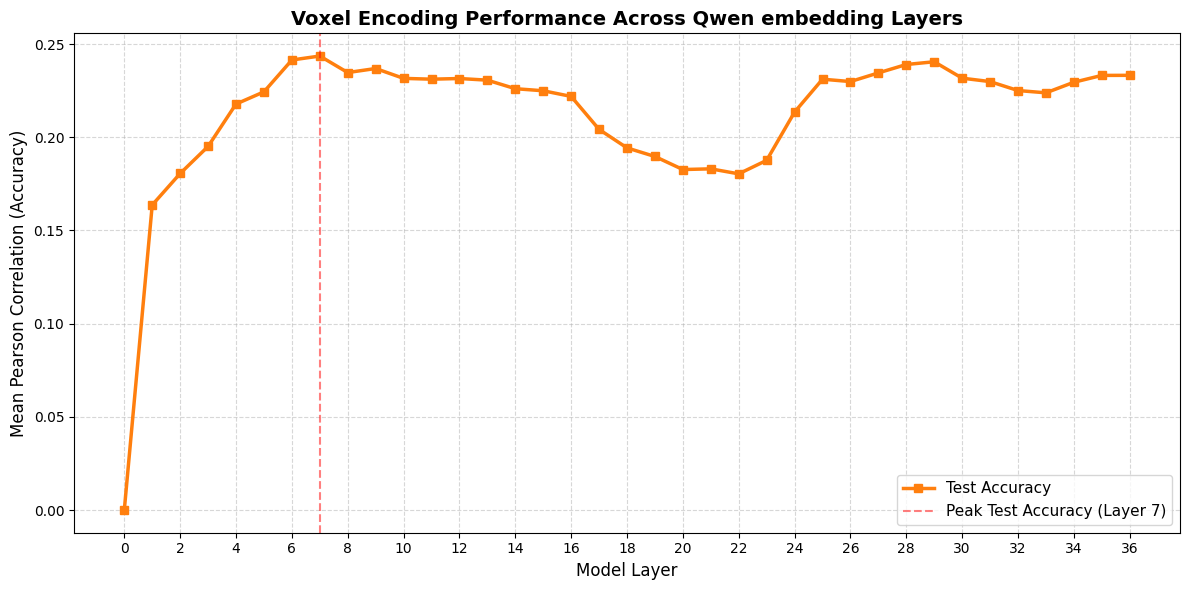

In [12]:
layer_performances = np.load(output_file, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

layer_performances = np.load(
output_file_embedding, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen embedding Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

For All Particpants

In [13]:
participants = ["M02", "M03", "M04", "M07", "M08", "M09", "M14", "M15", "P01"]
num_layers = 37
n_splits = 5
kf = KFold(n_splits=n_splits)
alphas = np.logspace(1, 20, 20)

In [14]:
all_accs_qwen_exp2 = np.zeros((len(participants), num_layers))
all_accs_qwen_exp3 = np.zeros((len(participants), num_layers))
all_accs_embedder_exp2 = np.zeros((len(participants), num_layers))
all_accs_embedder_exp3 = np.zeros((len(participants), num_layers))

In [15]:
def run_cv_pipeline(X, Y):
    _, n_voxels = Y.shape
    accs_train = np.empty((n_splits, n_voxels))
    accs_test = np.empty((n_splits, n_voxels))

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test[i] = correlation_score(Y_test, preds_test)

    mean_test_acc = accs_test.mean(axis=0).mean()
    mean_train_acc = accs_train.mean(axis=0).mean()
    
    return mean_test_acc, mean_train_acc

In [18]:
brain_data = {}
for participant in participants:
    print(f"data for {participant}...")
    brain_data[participant] = {'exp2': None, 'exp3': None}
    mat_exp3 = f"/home/scur0412/NeuroNLP/data/participants/{participant}/data_243sentences.mat"
    mat_exp2 = f"/home/scur0412/NeuroNLP/data/participants/{participant}/data_384sentences.mat"
    
    if os.path.exists(mat_exp2):
        brain_data[participant]['exp2'] = get_language_responses(mat_exp2)
    else:
        print(f"Missing Exp 2 data for {participant}")

    if os.path.exists(mat_exp3):
        brain_data[participant]['exp3'] = get_language_responses(mat_exp3)
    else:
        print(f" Missing Exp 3 data for {participant}")

data for M02...


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Dimensionality of brain responses: (384, 4930)
Dimensionality of brain responses: (243, 4930)
data for M03...
Missing Exp 2 data for M03
Dimensionality of brain responses: (243, 3616)
data for M04...
Dimensionality of brain responses: (384, 5906)
Dimensionality of brain responses: (243, 5906)
data for M07...
Dimensionality of brain responses: (384, 5629)
Dimensionality of brain responses: (243, 5629)
data for M08...
Dimensionality of brain responses: (384, 5083)
 Missing Exp 3 data for M08
data for M09...
Dimensionality of brain responses: (384, 3513)
 Missing Exp 3 data for M09
data for M14...
Dimensionality of brain responses: (384, 5225)
 Missing Exp 3 data for M14
data for M15...
Missing Exp 2 data for M15
 Missing Exp 3 data for M15
data for P01...
Dimensionality of brain responses: (384, 5265)
Dimensionality of brain responses: (243, 5265)


In [19]:
for layer_idx in range(num_layers):  
    print(f"Layer {layer_idx}")

    x_qwen_exp2 = np.load(os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_qwen_exp3 = np.load(os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    x_emb_exp2  = np.load(os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_emb_exp3  = np.load(os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy"))

    for p_idx, participant in enumerate(participants):

        y_exp2 = brain_data[participant]['exp2']
        y_exp3 = brain_data[participant]['exp3']

        if y_exp2 is not None:
            test_qwen_e2, _ = run_cv_pipeline(x_qwen_exp2, y_exp2)
            all_accs_qwen_exp2[p_idx, layer_idx] = test_qwen_e2

            test_emb_e2, _ = run_cv_pipeline(x_emb_exp2, y_exp2)
            all_accs_embedder_exp2[p_idx, layer_idx] = test_emb_e2

        if y_exp3 is not None:
            test_qwen_e3, _ = run_cv_pipeline(x_qwen_exp3, y_exp3)
            all_accs_qwen_exp3[p_idx, layer_idx] = test_qwen_e3

            test_emb_e3, _ = run_cv_pipeline(x_emb_exp3, y_exp3)
            all_accs_embedder_exp3[p_idx, layer_idx] = test_emb_e3

Layer 0
Layer 1
Layer 2
Layer 3
Layer 4
Layer 5
Layer 6
Layer 7
Layer 8
Layer 9
Layer 10
Layer 11
Layer 12
Layer 13
Layer 14
Layer 15
Layer 16
Layer 17
Layer 18
Layer 19
Layer 20
Layer 21
Layer 22
Layer 23
Layer 24
Layer 25
Layer 26
Layer 27
Layer 28
Layer 29
Layer 30
Layer 31
Layer 32
Layer 33
Layer 34
Layer 35
Layer 36


In [20]:
output_dir = "/home/scur0412/NeuroNLP/results"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "qwen_layer_performances_exp2.npy"), all_accs_qwen_exp2)
np.save(os.path.join(output_dir, "qwen_embedding_layer_performances_exp2.npy"), all_accs_embedder_exp2)
np.save(os.path.join(output_dir, "qwen_layer_performances_exp3.npy"), all_accs_qwen_exp3)
np.save(os.path.join(output_dir, "qwen_embedding_layer_performances_exp3.npy"), all_accs_embedder_exp3)

In [21]:
def plot_all_participants(data_matrix, title):
    plt.figure(figsize=(12, 6))
    
    for p_idx, participant in enumerate(participants):
        if np.all(np.isnan(data_matrix[p_idx])):
            continue
            
        plt.plot(layers, data_matrix[p_idx, :], marker='.', label=participant, 
                 color=colors[p_idx], linewidth=1.5, alpha=0.8)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Model Layer", fontsize=12)
    plt.ylabel("Mean Pearson Correlation", fontsize=12)
    plt.xticks(np.arange(0, num_layers, 2))
    plt.legend(title="Participants", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [22]:
def plot_averages(qwen_matrix, embedder_matrix, exp_name):
    avg_qwen = np.nanmean(qwen_matrix, axis=0)
    avg_embedder = np.nanmean(embedder_matrix, axis=0)

    plt.figure(figsize=(12, 6))
    plt.plot(layers, avg_qwen, marker='s', label='LLM (Average)', color='#1f77b4', linewidth=3)
    plt.plot(layers, avg_embedder, marker='o', label='Embedder (Average)', color='#ff7f0e', linewidth=3)

    plt.title(f"Average Performance: LLM vs. Embedder ({exp_name})", fontsize=14, fontweight='bold')
    plt.xlabel("Model Layer", fontsize=12)
    plt.ylabel("Mean Pearson Correlation", fontsize=12)
    plt.xticks(np.arange(0, num_layers, 2))
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [23]:
accs_qwen_exp2 = np.load(os.path.join(output_dir, "qwen_layer_performances_exp2.npy"))
accs_emb_exp2 = np.load(os.path.join(output_dir, "qwen_embedding_layer_performances_exp2.npy"))
accs_qwen_exp3 = np.load(os.path.join(output_dir, "qwen_layer_performances_exp3.npy"))
accs_emb_exp3 = np.load(os.path.join(output_dir, "qwen_embedding_layer_performances_exp3.npy"))

In [24]:
layers = np.arange(num_layers)  
colors = plt.cm.tab10.colors

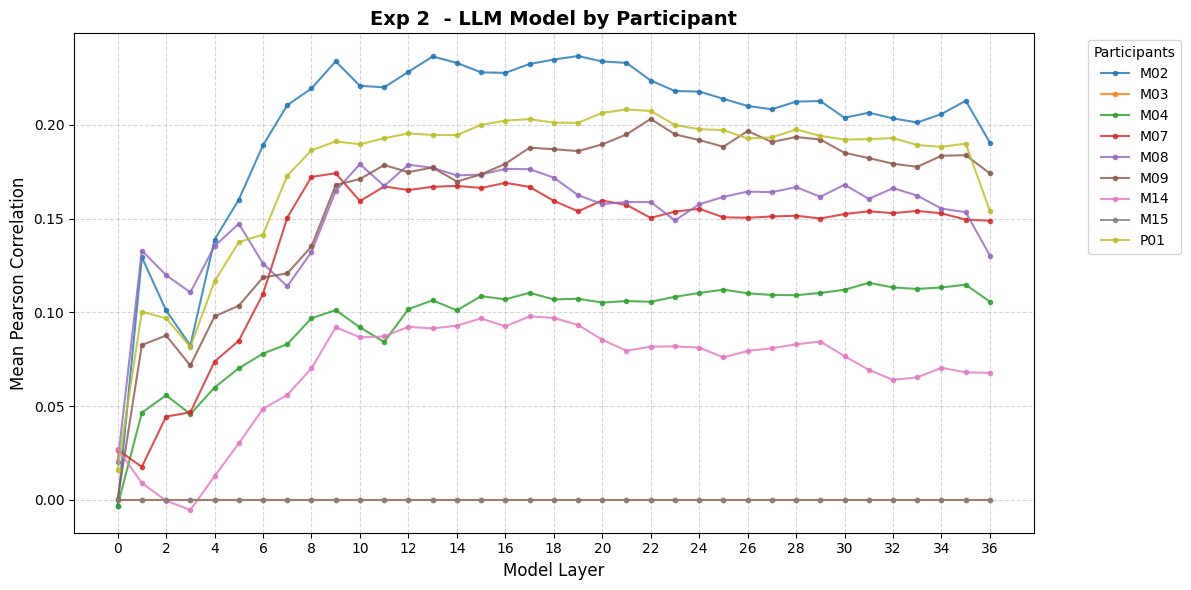

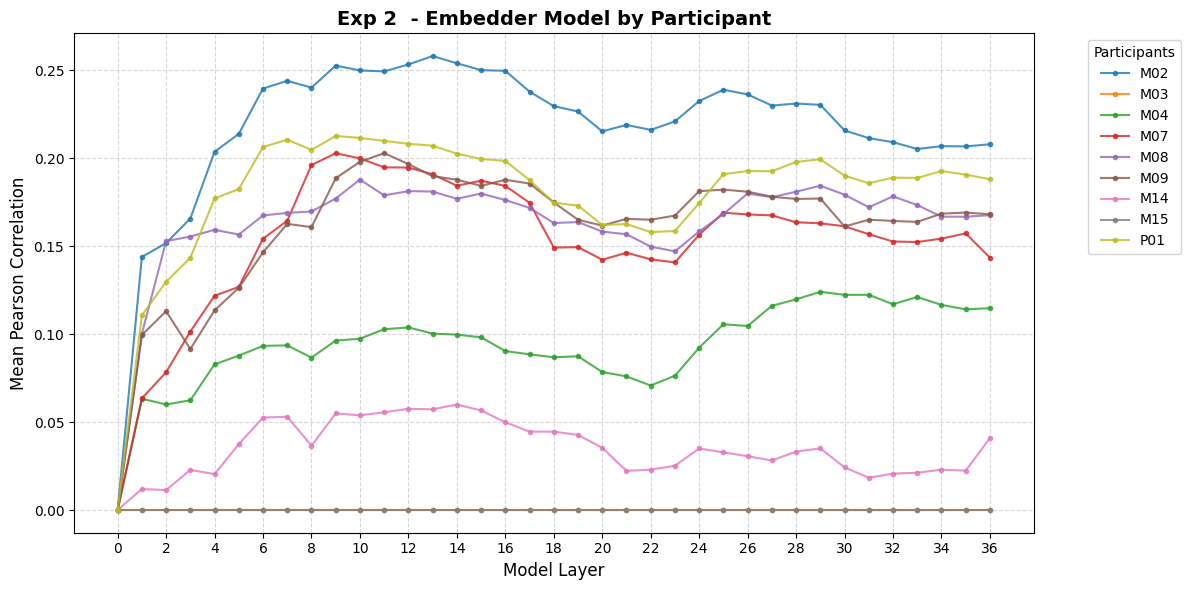

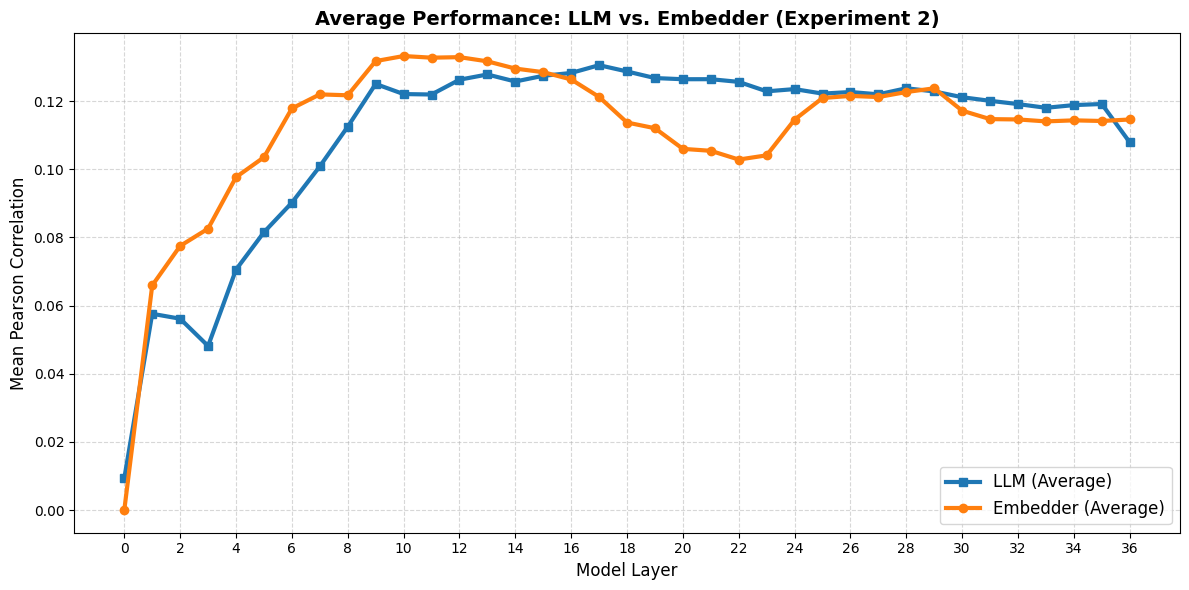

In [25]:
plot_all_participants(accs_qwen_exp2, "Exp 2  - LLM Model by Participant")
plot_all_participants(accs_emb_exp2, "Exp 2  - Embedder Model by Participant")
plot_averages(accs_qwen_exp2, accs_emb_exp2, "Experiment 2")

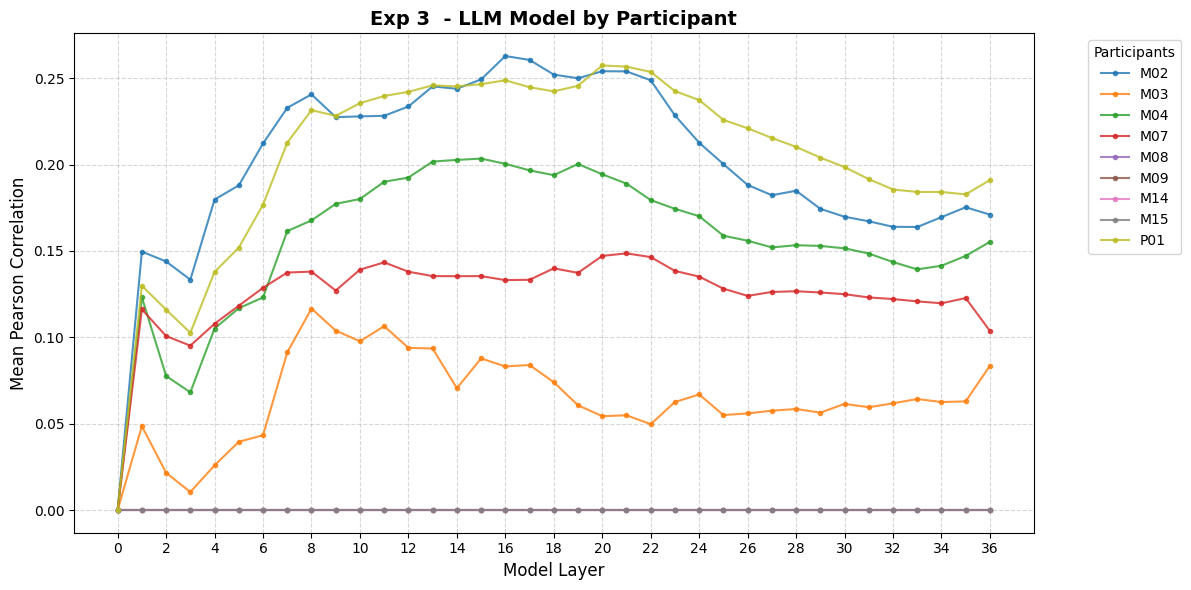

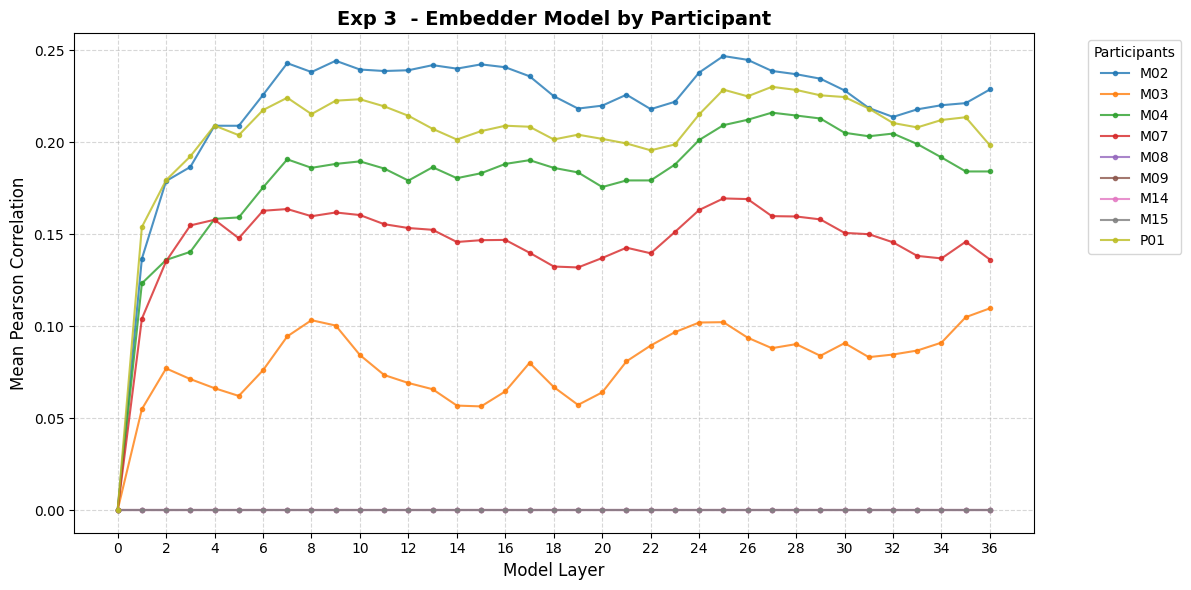

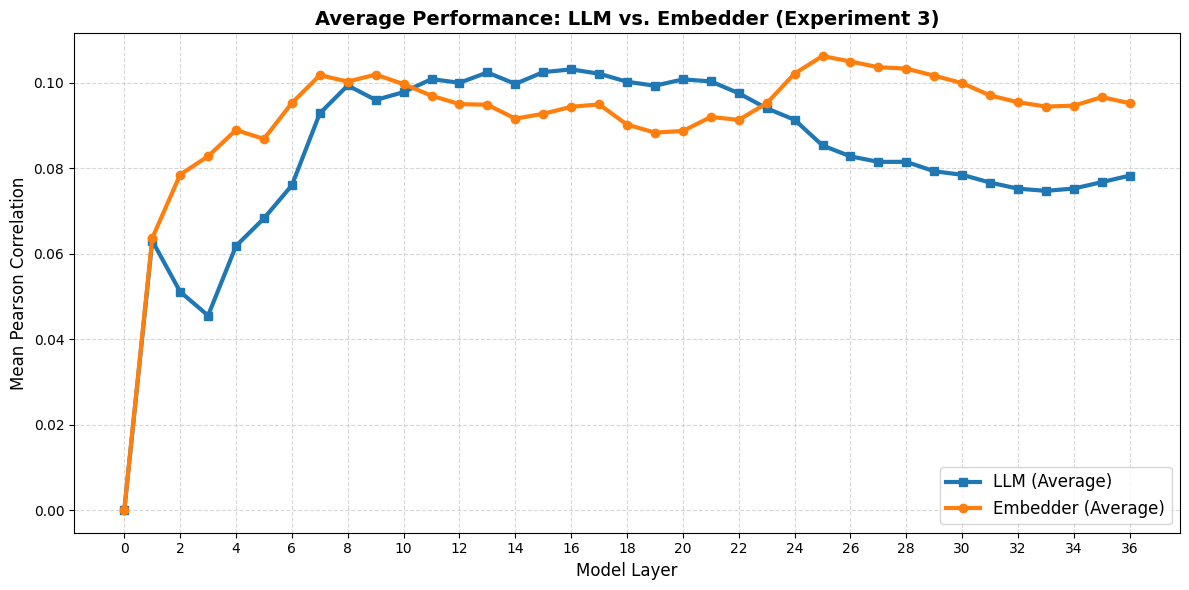

In [26]:
plot_all_participants(accs_qwen_exp3, "Exp 3  - LLM Model by Participant")
plot_all_participants(accs_emb_exp3, "Exp 3  - Embedder Model by Participant")
plot_averages(accs_qwen_exp3, accs_emb_exp3, "Experiment 3")